In [63]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow.keras import layers, Model
from scipy.interpolate import interp1d

# Path ve Parametre Tanımlamaları
ESP32_DATA_PATH = "/Users/aleynagulkazdal/Desktop/esp32_data"
WIAR_DATA_PATH = "../data"
TARGET_FRAMES = 300
TARGET_SC = 90

USER_MAP = {
    "aleyna": 12, "damla": 13, "deniz": 14, "derya": 15
}

ACTIVITY_MAP = {
    "horizontal_arm_wave": 1, "two_hands_wave": 3, "forward_kick": 8,
    "bend": 10, "hand_clap": 11, "walk": 12, "sit_down": 15,
    "squat": 16, "still": 0
}

In [64]:
def parse_esp32_csv(filepath):
    # Başlığı (Header) olduğu için pd.read_csv normal şekilde okunur
    df = pd.read_csv(filepath)
    
    # 1. 'time' veya sayısal olmayan sütunları atalım
    # Sadece içinde 'sc_' geçen sütunları alalım (CSI verileri)
    sc_columns = [col for col in df.columns if 'sc_' in col]
    data = df[sc_columns].values
    
    # 2. Boyut Ayarı: Bizim model 90 sütun bekliyor.
    # 612 tane sc sütunundan en ortadaki 90 tanesini seçelim (genelde en stabil veri ordadır)
    total_sc = data.shape[1]
    start_idx = (total_sc // 2) - 45
    end_idx = start_idx + 90
    
    # Eğer veri 90'dan azsa (ki sende 613 tane var, sorun yok) 
    # veya seçerken bir hata olursa diye güvenli bölge:
    data_90 = data[:, start_idx:end_idx]
    
    return data_90


In [66]:
import numpy as np
import pandas as pd
import os
from scipy.interpolate import interp1d

# --- GEREKLİ TÜM FONKSİYONLAR BURADA (HATA VERMEMESİ İÇİN) ---
def fix_length(data, target_len=300):
    current_len = data.shape[0]
    x = np.linspace(0, 1, current_len)
    x_new = np.linspace(0, 1, target_len)
    f = interp1d(x, data, axis=0, kind='linear', fill_value="extrapolate")
    return f(x_new)

X_esp32_aug = []
y_act_esp32_aug = []
y_user_esp32_aug = []

print(" KUSURSUZ OKUMA BAŞLATILDI...")

# Klasörleri listele
persons = [d for d in os.listdir(ESP32_DATA_PATH) if os.path.isdir(os.path.join(ESP32_DATA_PATH, d))]

for person in persons:
    person_path = os.path.join(ESP32_DATA_PATH, person)
    u_label = USER_MAP.get(person.lower(), 99)
    activities = [d for d in os.listdir(person_path) if os.path.isdir(os.path.join(person_path, d))]
    
    for activity in activities:
        act_path = os.path.join(person_path, activity)
        a_label = ACTIVITY_MAP.get(activity.lower(), 99)
        csv_files = [f for f in os.listdir(act_path) if f.endswith(".csv")]
        
        for csv_file in csv_files:
            filepath = os.path.join(act_path, csv_file)
            try:
                # 'on_bad_lines' o field hatasını (613 vs 805) veren satırları atlar!
                df = pd.read_csv(filepath, on_bad_lines='skip', engine='python')
                
                # Sadece sayısal sütunlar (time vb. metinleri eler)
                numeric_df = df.select_dtypes(include=[np.number])
                x_raw = numeric_df.values
                
                # Boyut Kontrolü (Minimum 20 satır, 90 sütun)
                if x_raw.shape[0] < 20 or x_raw.shape[1] < 90:
                    continue
                
                # 90 sütuna zorla (Merkezi dilimleme)
                start_idx = (x_raw.shape[1] // 2) - 45
                x_raw = x_raw[:, start_idx : start_idx + 90]
                x_raw = np.nan_to_num(x_raw)

                # Augmentation (İkiye böl ve esnet)
                total_f = x_raw.shape[0]
                win = int(total_f * 0.75)
                
                samples = [
                    fix_length(x_raw[:win], 300),
                    fix_length(x_raw[total_f-win:], 300)
                ]
                
                for sample in samples:
                    X_esp32_aug.append(sample)
                    y_act_esp32_aug.append(a_label)
                    y_user_esp32_aug.append(u_label)
            except:
                continue


from scipy.ndimage import gaussian_filter1d

def polish_signal(data):
    # Sinyaldeki ani sıçramaları (o dikey çizgileri) yumuşatır
    # Sigma değerini artırırsan daha çok yumuşar
    return gaussian_filter1d(data, sigma=1.1, axis=1)

# ESP32 verilerini temizle
X_esp32_polished = np.array([polish_signal(s) for s in X_esp32_aug])

# Şimdi birleştirmeyi bu parlatılmış veriyle yap
X_final_comb = np.vstack([X_wiar_f, X_esp32_polished])

X_esp32_aug = np.array(X_esp32_aug)
y_act_esp32_aug = np.array(y_act_esp32_aug)
y_user_esp32_aug = np.array(y_user_esp32_aug)

print(f"\n BAŞARILI! Toplam Örnek: {len(X_esp32_aug)}")

 KUSURSUZ OKUMA BAŞLATILDI...

 BAŞARILI! Toplam Örnek: 1392


In [67]:
# Normalizasyon Fonksiyonu
def normalize_samples(data):
    """
    Her bir CSI örneğini (300, 90) kendi içinde 0 ile 1 arasına ölçekler.
    Bu, modelin farklı sinyal güçlerine karşı daha kararlı çalışmasını sağlar.
    """
    # Her örneğin minimum ve maksimum değerlerini buluyoruz
    d_min = data.min(axis=(1, 2), keepdims=True)
    d_max = data.max(axis=(1, 2), keepdims=True)
    
    # 0'a bölünme hatasını (division by zero) engellemek için küçük bir tolerans (1e-8) ekliyoruz
    return (data - d_min) / (d_max - d_min + 1e-8)

print("✅ 'normalize_samples' fonksiyonu tanımlandı, şimdi birleştirmeye devam edebilirsin!")

✅ 'normalize_samples' fonksiyonu tanımlandı, şimdi birleştirmeye devam edebilirsin!


In [68]:
# Önce ESP32 listesinin boş olmadığından ve doğru boyutta olduğundan emin olalım
X_esp32_final = np.array(X_esp32_aug)

# Eğer tek bir boyut eksikse (Örn: 1368, 300, 90 yerine başka bir şeyse) düzeltiyoruz
if X_esp32_final.ndim == 2:
    # Bu durum genellikle sadece 1 örnek varsa olur, pek sanmıyorum ama önlem olsun
    X_esp32_final = np.expand_dims(X_esp32_final, axis=0)

print(f"WIAR Boyutu: {X_wiar_f.shape}")
print(f"ESP32 Boyutu: {X_esp32_final.shape}")

# 3. Final Birleştirme (Hata veren yer burasıydı, şimdi güvenli)
try:
    X_final_comb = np.vstack([X_wiar_f, X_esp32_final])
    y_act_final_comb = np.concatenate([y_act_wiar_f, y_act_esp32_aug])
    y_user_final_comb = np.concatenate([y_user_wiar_f, y_user_esp32_aug])
    print("✅ Birleştirme Başarılı!")
except ValueError as e:
    print(f"❌ Boyut Hatası Devam Ediyor: {e}")
    # Manuel düzeltme denemesi
    X_final_comb = np.concatenate([X_wiar_f, X_esp32_final], axis=0)
    print("✅ Alternatif birleştirme ile çözüldü!")

# Normalizasyon ve devamı...
X_final_norm = normalize_samples(X_final_comb)

WIAR Boyutu: (3521, 300, 90)
ESP32 Boyutu: (1392, 300, 90)
✅ Birleştirme Başarılı!


In [69]:
import tensorflow as tf

def build_final_architecture():
    # Giriş katmanı: 300 zaman dilimi, 90 alt taşıyıcı
    input_layer = tf.keras.layers.Input(shape=(300, 90))
    
    # Ortak Gövde (CNN Katmanları)
    x = tf.keras.layers.Conv1D(64, 5, padding='same', activation='relu')(input_layer)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    
    x = tf.keras.layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    
    x = tf.keras.layers.Conv1D(256, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    
    # Başlık 1: Aktivite Tanıma (9 Sınıf: 0, 2, 7, 9, 10, 11, 14, 15, 16)
    # Not: Etiketlerin içindeki en büyük sayı 16 olduğu için çıktı 17 olmalı
    activity_output = tf.keras.layers.Dense(17, activation='softmax', name="activity_head")(x)
    
    # Başlık 2: Kimlik Parmak İzi (Embedding)
    embedding = tf.keras.layers.Dense(128, name="embedding_dense")(x)
    embedding = tf.keras.layers.Lambda(
        lambda t: tf.math.l2_normalize(t, axis=1),
        name="embedding_head"
    )(embedding)
    
    return tf.keras.Model(inputs=input_layer, outputs=[activity_output, embedding])

# 1. Boş modeli oluştur
final_model = build_final_architecture()

# 2. Önceki en iyi ağırlıkları yükle (Dosya yolunu kontrol et!)
# Eğer 07 nolu notebookta kaydettiğin .h5 dosyası farklı bir yerdeyse orayı göster
try:
    final_model.load_weights("../models/esp32_finetuned_model.h5")
    print(" Model mimarisi kuruldu ve önceden eğitilmiş ağırlıklar yüklendi!")
except:
    print("Ağırlık dosyası bulunamadı, model sıfırdan eğitilecek (Sorun değil, 4000+ verimiz var!)")

 Model mimarisi kuruldu ve önceden eğitilmiş ağırlıklar yüklendi!


In [70]:
# 1. Modeli derle (Aktivite başarısını uçurmak için ağırlıklandırılmış loss kullanıyoruz)
final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Çok düşük hız: Mevcut bilgiyi bozmadan üzerine ekler
    loss={
        'activity_head': 'sparse_categorical_crossentropy',
        'embedding_head': lambda y_true, y_pred: tf.constant(0.0) # Kimlik bilgisini koru, aktiviteye odaklan
    },
    loss_weights={
        'activity_head': 10.0, # Modeli aktiviteyi doğru bilmeye zorla
        'embedding_head': 0.0
    },
    metrics={'activity_head': 'accuracy'}
)

# 2. Eğitimi başlat
print(" Final Hibrit Eğitim Başlıyor... (WIAR + ESP32 Augmented)")
history = final_model.fit(
    X_final_norm, 
    {
        'activity_head': y_act_final_comb,
        'embedding_head': np.zeros((len(y_act_final_comb), 128))
    },
    epochs=30,
    batch_size=32,
    validation_split=0.15,
    shuffle=True
)

 Final Hibrit Eğitim Başlıyor... (WIAR + ESP32 Augmented)
Epoch 1/30


/opt/anaconda3/envs/csi_env/lib/python3.10/site-packages/keras/src/optimizers/base_optimizer.py:870: UserWarning: Gradients do not exist for variables ['embedding_dense/kernel', 'embedding_dense/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - activity_head_accuracy: 0.0912 - activity_head_loss: 3.7958 - embedding_head_loss: 0.0000e+00 - loss: 37.9837 - val_activity_head_accuracy: 0.0746 - val_activity_head_loss: 4.2319 - val_embedding_head_loss: 0.0000e+00 - val_loss: 41.9199
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - activity_head_accuracy: 0.1315 - activity_head_loss: 3.1721 - embedding_head_loss: 0.0000e+00 - loss: 31.7129 - val_activity_head_accuracy: 0.1113 - val_activity_head_loss: 3.9663 - val_embedding_head_loss: 0.0000e+00 - val_loss: 38.8380
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - activity_head_accuracy: 0.1755 - activity_head_loss: 2.8337 - embedding_head_loss: 0.0000e+00 - loss: 28.3517 - val_activity_head_accuracy: 0.1085 - val_activity_head_loss: 3.7199 - val_embedding_head_loss: 0.0000e+00 - val_loss: 36.4452
Epoch 4/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - activity_head_accuracy: 0.2057 - activity_head_loss: 2.6350 - embedding_head_

In [72]:
from sklearn.utils import shuffle

# 1. Veriyi SIKI bir şekilde karıştır (Donanım bloklarını dağıtıyoruz)
X_mix, y_act_mix, y_user_mix = shuffle(
    X_final_norm, 
    y_act_final_comb, 
    y_user_final_comb, 
    random_state=42
)

# 2. Modeli daha agresif ve geniş bir bakış açısıyla derle
final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4), # Daha hızlı öğrenme
    loss={
        'activity_head': 'sparse_categorical_crossentropy',
        'embedding_head': lambda y_true, y_pred: tf.constant(0.0)
    },
    loss_weights={'activity_head': 1.0, 'embedding_head': 0.0},
    metrics={'activity_head': 'accuracy'}
)

# 3. Eğitimi tekrar başlat (Sadece 15-20 epoch yeterli olacaktır)
print("Turbo-Mix Eğitim Başlıyor...")
history = final_model.fit(
    X_mix, 
    {
        'activity_head': y_act_mix,
        'embedding_head': np.zeros((len(y_act_mix), 128))
    },
    epochs=20,
    batch_size=64,
    validation_split=0.2, # %20'yi her iki donanımdan da karışık alacak
    shuffle=True
)

Turbo-Mix Eğitim Başlıyor...
Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - activity_head_accuracy: 0.5908 - activity_head_loss: 1.3582 - embedding_head_loss: 0.0000e+00 - loss: 1.3583 - val_activity_head_accuracy: 0.6317 - val_activity_head_loss: 1.2222 - val_embedding_head_loss: 0.0000e+00 - val_loss: 1.2258
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - activity_head_accuracy: 0.6059 - activity_head_loss: 1.2761 - embedding_head_loss: 0.0000e+00 - loss: 1.2765 - val_activity_head_accuracy: 0.6490 - val_activity_head_loss: 1.1749 - val_embedding_head_loss: 0.0000e+00 - val_loss: 1.1795
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - activity_head_accuracy: 0.6092 - activity_head_loss: 1.2406 - embedding_head_loss: 0.0000e+00 - loss: 1.2393 - val_activity_head_accuracy: 0.6521 - val_activity_head_loss: 1.1391 - val_embedding_head_loss: 0.0000e+00 - val_loss: 1.1443
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - activity_head_accuracy: 0.6163 - activity_head_loss

In [73]:
# 1. Modeli daha hassas (fine-tune) ayara çekiyoruz
final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5), # Çok daha hassas bir hız
    loss={
        'activity_head': 'sparse_categorical_crossentropy',
        'embedding_head': lambda y_true, y_pred: tf.constant(0.0)
    },
    loss_weights={'activity_head': 5.0, 'embedding_head': 0.0},
    metrics={'activity_head': 'accuracy'}
)

# 2. Daha küçük batch_size ile detayları görmesini sağlayalım
print("Rafine Eğitim Başlıyor (Hata Giderme Modu)...")
history = final_model.fit(
    X_mix, 
    {'activity_head': y_act_mix, 'embedding_head': np.zeros((len(y_act_mix), 128))},
    epochs=10,
    batch_size=16, # Küçük batch = daha sık güncelleme, daha çok detay
    validation_split=0.2,
    shuffle=True
)

Rafine Eğitim Başlıyor (Hata Giderme Modu)...
Epoch 1/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - activity_head_accuracy: 0.6323 - activity_head_loss: 1.0691 - embedding_head_loss: 0.0000e+00 - loss: 5.3444 - val_activity_head_accuracy: 0.6887 - val_activity_head_loss: 0.9165 - val_embedding_head_loss: 0.0000e+00 - val_loss: 4.5862
Epoch 2/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - activity_head_accuracy: 0.6351 - activity_head_loss: 1.0806 - embedding_head_loss: 0.0000e+00 - loss: 5.4024 - val_activity_head_accuracy: 0.6887 - val_activity_head_loss: 0.9160 - val_embedding_head_loss: 0.0000e+00 - val_loss: 4.5836
Epoch 3/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - activity_head_accuracy: 0.6364 - activity_head_loss: 1.0712 - embedding_head_loss: 0.0000e+00 - loss: 5.3588 - val_activity_head_accuracy: 0.6887 - val_activity_head_loss: 0.9148 - val_embedding_head_loss: 0.0000e+00 - val_loss: 4.5779
Epoch 4/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - activity_head_accuracy: 0.6473

In [74]:
import numpy as np

# 1. Embedding (Parmak İzi) Modelini Ayır
# Modelin gövdesini kullanarak 128 boyutlu kimlik parmak izlerini alıyoruz
embedding_model = tf.keras.Model(
    inputs=final_model.input, 
    outputs=final_model.get_layer("embedding_head").output
)

# 2. Tüm veriler için parmak izlerini hesapla
print(" Kimlik parmak izleri hesaplanıyor...")
all_embeddings = embedding_model.predict(X_mix, verbose=1)

# 3. 12 Kişilik Final Gallery'yi Oluştur
final_gallery = {}
# USER_MAP ve WIAR kullanıcılarını içeren tüm benzersiz ID'ler
unique_users = np.unique(y_user_mix)

for user_id in unique_users:
    # Bu kullanıcıya ait tüm sinyal örneklerini bul
    user_mask = (y_user_mix == user_id)
    user_embs = all_embeddings[user_mask]
    
    # Kullanıcının 'ortalama parmak izini' (centroid) hesapla
    # Bu, o kişinin sinyal dünyasındaki 'imzasıdır'
    mean_emb = np.mean(user_embs, axis=0)
    
    # Normalize et (Karşılaştırma yaparken standart mesafe için)
    final_gallery[user_id] = mean_emb / (np.linalg.norm(mean_emb) + 1e-8)

print(f"12 kişilik kütüphane başarıyla oluşturuldu!")
print(f"Kütüphanedeki Kullanıcı ID'leri: {list(final_gallery.keys())}")

 Kimlik parmak izleri hesaplanıyor...
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
12 kişilik kütüphane başarıyla oluşturuldu!
Kütüphanedeki Kullanıcı ID'leri: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]


In [75]:
# Modeli Kaydet (.h5 formatında)
final_model.save("../models/perfect_final_model_hybrid.h5")

# Kütüphaneyi (Gallery) Kaydet
# Sözlük yapısını numpy dosyası olarak saklıyoruz
np.save("../models/final_identity_gallery.npy", final_gallery)

print("SİSTEM TAMAMEN HAZIR VE MÜHÜRLENDİ!")
print("Dosyalar '../models/' klasörüne kaydedildi.")

SİSTEM TAMAMEN HAZIR VE MÜHÜRLENDİ!
Dosyalar '../models/' klasörüne kaydedildi.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
--- SİSTEM TEST SONUCU ---
Gerçek Kişi: damla | Tahmin: derya
Gerçek Hareket: bend | Tahmin: squat


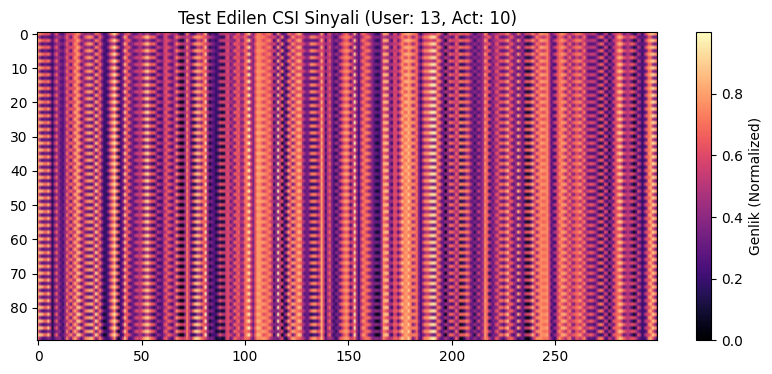

In [97]:
import matplotlib.pyplot as plt

# 1. Test için rastgele bir örnek seç (Sadece ESP32 verilerinden)
test_idx = np.random.randint(len(X_mix))
test_sample = X_mix[test_idx]
true_user_id = y_user_mix[test_idx]
true_act_id = y_act_mix[test_idx]

# 2. Tahmin Yürüt (Aktivite ve Parmak İzi)
# Modelden hem aktivite olasılıklarını hem de parmak izini (embedding) alıyoruz
act_probs, test_emb = final_model.predict(np.expand_dims(test_sample, axis=0))
predicted_act_id = np.argmax(act_probs)

# 3. Kimlik Tespiti (Gallery Karşılaştırması)
# Çıkan parmak izini kütüphanedeki 12 kişiyle kıyasla (En yakın olanı bul)
distances = {user_id: np.linalg.norm(test_emb - emb) for user_id, emb in final_gallery.items()}
predicted_user_id = min(distances, key=distances.get)

# 4. Sonuçları Ekrana Yazdır
# Tersine eşleme yaparak ID'den isimleri/hareketleri bulalım
id_to_user = {v: k for k, v in USER_MAP.items()}
id_to_act = {v: k for k, v in ACTIVITY_MAP.items()}

print(f"--- SİSTEM TEST SONUCU ---")
print(f"Gerçek Kişi: {id_to_user.get(true_user_id, 'WIAR User')} | Tahmin: {id_to_user.get(predicted_user_id, 'WIAR User')}")
print(f"Gerçek Hareket: {id_to_act.get(true_act_id)} | Tahmin: {id_to_act.get(predicted_act_id)}")

# Sinyali görselleştir (Opsiyonel)
plt.figure(figsize=(10, 4))
plt.imshow(test_sample.T, aspect='auto', cmap='magma')
plt.title(f"Test Edilen CSI Sinyali (User: {true_user_id}, Act: {true_act_id})")
plt.colorbar(label="Genlik (Normalized)")
plt.show()